```{contents}
```
## Bias, Variance, and Their Trade-off

### Bias

Bias measures how far a model’s predictions are from the true underlying function.

Mathematically, for estimator $\hat{f}(x)$:

$$
\text{Bias}(x) = \mathbb{E}[\hat{f}(x)] - f(x)
$$

Interpretation:

* High bias = model is too simple.
* Leads to **underfitting**.
* Model learns only coarse patterns and ignores important structure.

Examples:

* Using linear regression for a non-linear problem.
* Using few decision tree splits.

Effects:

* High training error
* High testing error
* Model predictions look overly smooth or simplistic.

---

### Variance

Variance measures how sensitive the model is to small fluctuations in training data.

$$
\text{Variance}(x) = \mathbb{E}\big[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2\big]
$$

Interpretation:

* High variance = model is too complex.
* Leads to **overfitting**.
* The model memorizes noise instead of learning general patterns.

Examples:

* Deep decision trees
* High-degree polynomial regression
* kNN with very small (k)

Effects:

* Low training error
* High testing error
* Model curves wildly to chase noise in data.

---

###  Total Error (Bias–Variance Decomposition)**

For a regression problem with:

* True function $f(x)$,
* Model prediction $\hat{f}(x)$,
* Noise variance $\sigma^2$,

Expected prediction error at point (x) is:

$$
\mathbb{E}[(y - \hat{f}(x))^2]
= \underbrace{\text{Bias}^2}_{\text{error from wrong assumptions}}

* \underbrace{\text{Variance}}_{\text{error from sensitivity}}
* \underbrace{\sigma^2}_{\text{irreducible noise}}
$$

Irreducible noise cannot be removed.

---

### The Bias–Variance Trade-off

A model cannot simultaneously minimize both bias and variance; improving one often worsens the other.

| Model Complexity | Bias   | Variance | Behavior     |
| ---------------- | ------ | -------- | ------------ |
| Low              | High   | Low      | Underfitting |
| Medium           | Medium | Medium   | Optimal zone |
| High             | Low    | High     | Overfitting  |

Key insight:

* **Increasing model complexity decreases bias but increases variance.**
* **Decreasing complexity increases bias but decreases variance.**

Goal:
Choose complexity that balances both → lowest test error.

---

### How to Reduce Bias

Use when model is too simple.

* Add more features
* Use more complex models
* Reduce regularization ((\lambda))
* Increase model capacity (depth, degree, layers)

---

### How to Reduce Variance

Use when the model is too sensitive.

* Add regularization (L1, L2)
* Reduce model complexity
* Use dropout (for NN)
* Use fewer polynomial degrees
* Prune trees or limit tree depth
* Increase training data
* Use bagging / random forests

---

### Visualization Summary

* **High Bias:** Predicts wrong shape; consistently incorrect.
* **High Variance:** Predicts wildly different shapes for small data changes.
* **Balanced:** Captures structure without fitting noise.



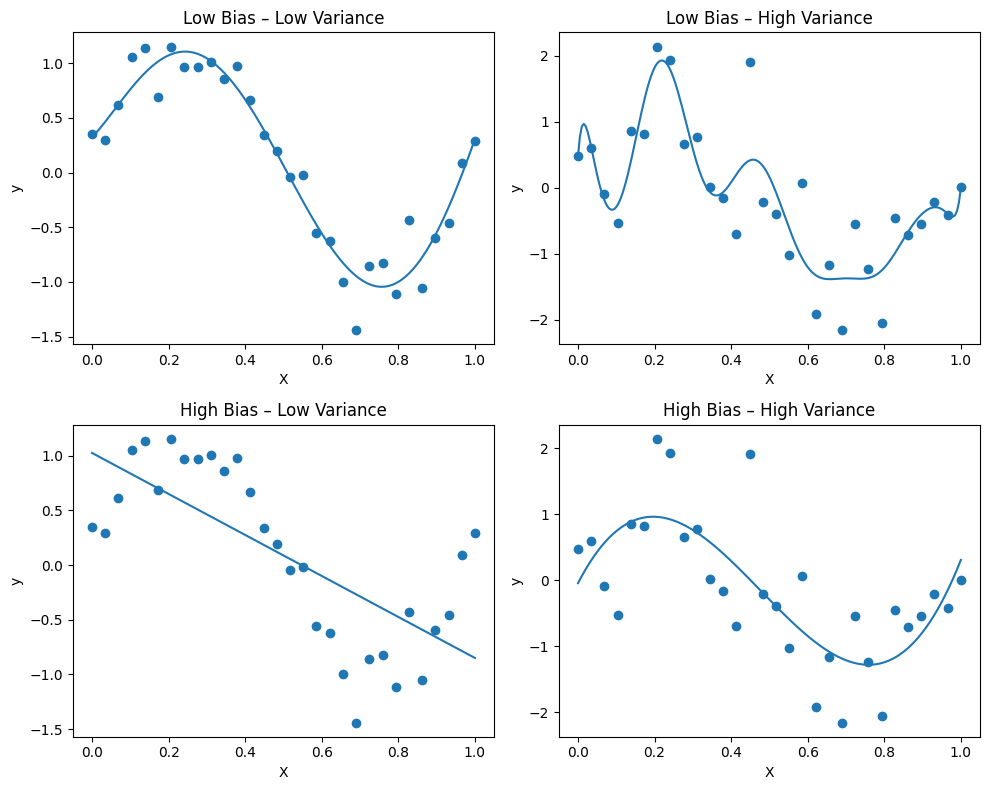

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil, sqrt

# Example: models dict
# models = { "Low Bias – Low Variance": model1, ... }

n = len(models)                        # number of plots
cols = ceil(sqrt(n))                   # square-like arrangement
rows = ceil(n / cols)

plt.figure(figsize=(cols * 5, rows * 4))

for i, (title, model) in enumerate(models.items(), 1):
    if "High Variance" in title:
        y_used = y + noise_extra
    else:
        y_used = y

    model.fit(X, y_used)
    X_test = np.linspace(0, 1, 200).reshape(-1, 1)
    y_pred = model.predict(X_test)

    ax = plt.subplot(rows, cols, i)
    ax.scatter(X, y_used)
    ax.plot(X_test, y_pred)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()